In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))
import config

PROCESSED_DIR = os.path.join("..", config.PROCESSED_DATA_DIR)
PLOTS_DIR     = os.path.join("..", config.OUTPUTS_PLOTS)
DAYTIME_THR   = config.DAYTIME_THR
CITIES        = list(config.CITIES.keys())

os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"      : 120,
    "axes.titlesize"  : 11,
    "axes.labelsize"  : 10,
    "legend.fontsize" : 8,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
})
CITY_COLORS = dict(zip(CITIES, plt.cm.tab10(np.linspace(0, 1, len(CITIES)))))

print("✅ Imports ready")

✅ Imports ready


In [2]:
city_dfs = {}

print("📂 Loading processed CSVs...\n")
for city in CITIES:
    path = os.path.join(PROCESSED_DIR, f"{city}_processed.csv")
    df   = pd.read_csv(path, index_col="datetime", parse_dates=True)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")

    # Add helper columns for grouping
    df["month"]      = df.index.month
    df["hour"]       = df.index.hour
    df["day_of_year"]= df.index.dayofyear
    df["year"]       = df.index.year
    df["is_daytime"] = df["GHI"] > DAYTIME_THR

    city_dfs[city] = df
    print(f"  ✅ {city:<14}  {df.shape}  "
          f"daytime_rows={df['is_daytime'].sum():,}")

# Combined dataframe for multi-city analysis
combined_df = pd.concat(
    [df.assign(city=city) for city, df in city_dfs.items()],
    axis=0
)
print(f"\n📋 Combined shape : {combined_df.shape}")

📂 Loading processed CSVs...

  ✅ riyadh          (26280, 15)  daytime_rows=13,131
  ✅ cairo           (26280, 15)  daytime_rows=13,173
  ✅ istanbul        (26280, 15)  daytime_rows=12,819
  ✅ new_delhi       (26280, 15)  daytime_rows=13,039
  ✅ dubai           (26280, 15)  daytime_rows=13,027
  ✅ london          (26280, 15)  daytime_rows=12,862
  ✅ sydney          (26280, 15)  daytime_rows=12,965
  ✅ tokyo           (26280, 15)  daytime_rows=12,894
  ✅ los_angeles     (26280, 15)  daytime_rows=13,191
  ✅ nairobi         (26280, 15)  daytime_rows=12,936

📋 Combined shape : (262800, 16)


In [3]:
FEATURE_COLS = [
    "GHI", "temperature", "wind_speed", "humidity",
    "clear_sky_ghi", "precipitation", "pressure", "clearness_index"
]

print("📊 STATISTICAL SUMMARY — ALL CITIES\n")
print("=" * 70)

all_stats = []
for city in CITIES:
    df    = city_dfs[city]
    stats_row = {"city": city}
    for col in FEATURE_COLS:
        stats_row[f"{col}_mean"] = round(df[col].mean(), 3)
        stats_row[f"{col}_std"]  = round(df[col].std(),  3)
        stats_row[f"{col}_max"]  = round(df[col].max(),  3)
    all_stats.append(stats_row)

stats_df = pd.DataFrame(all_stats).set_index("city")

# Print clean per-feature summary
for col in FEATURE_COLS:
    subset = stats_df[[f"{col}_mean", f"{col}_std", f"{col}_max"]]
    subset.columns = ["mean", "std", "max"]
    print(f"\n  {col.upper()}")
    print(subset.to_string())

print("\n✅ Statistical summary complete")

📊 STATISTICAL SUMMARY — ALL CITIES


  GHI
                mean      std      max
city                                  
riyadh       252.068  334.694  1084.70
cairo        238.573  317.302  1047.25
istanbul     168.260  247.634   981.40
new_delhi    195.817  271.728  1025.18
dubai        230.335  304.072  1033.62
london       125.718  190.957   925.03
sydney       193.148  274.193  1116.45
tokyo        167.872  240.518  1016.50
los_angeles  233.685  311.494  1063.35
nairobi      239.512  320.341  1117.20

  TEMPERATURE
               mean    std    max
city                             
riyadh       26.534  9.864  47.12
cairo        22.192  8.826  44.30
istanbul     15.738  7.681  37.48
new_delhi    24.979  8.913  47.49
dubai        29.029  5.960  44.17
london       11.019  6.565  34.53
sydney       18.576  3.834  35.91
tokyo        14.659  8.996  34.71
los_angeles  17.411  6.800  38.10
nairobi      20.402  5.004  33.69

  WIND_SPEED
              mean    std    max
city               

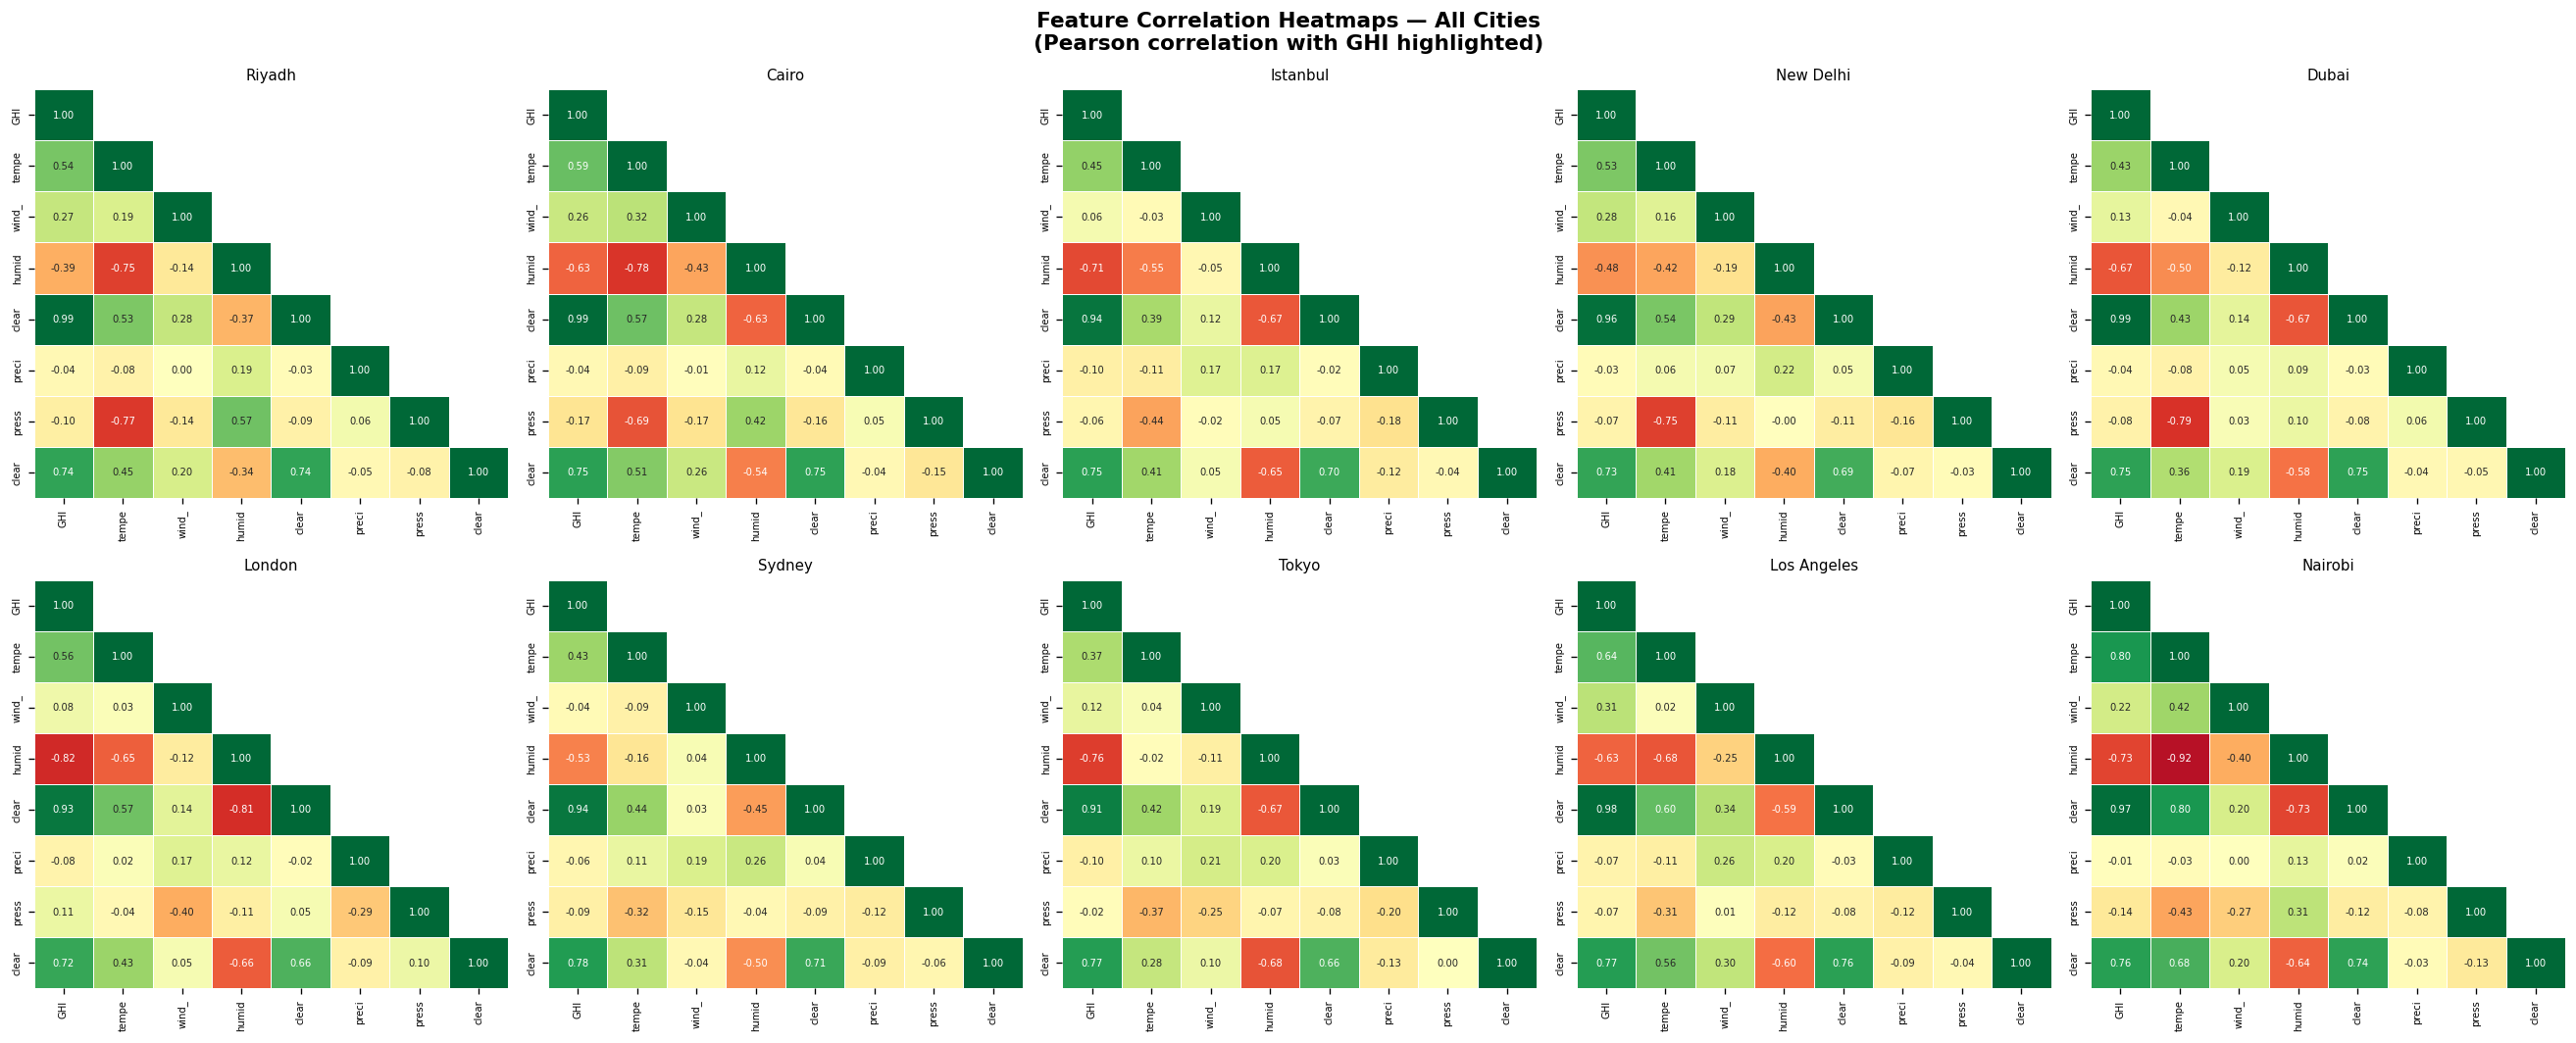

💾 Saved → ..\outputs/plots\03_correlation_heatmaps.png


In [4]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(
    "Feature Correlation Heatmaps — All Cities\n"
    "(Pearson correlation with GHI highlighted)",
    fontsize=13, fontweight="bold"
)

for idx, city in enumerate(CITIES):
    ax  = axes[idx // 5][idx % 5]
    df  = city_dfs[city][FEATURE_COLS].copy()
    corr = df.corr()

    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    sns.heatmap(
        corr, ax=ax, mask=mask,
        annot=True, fmt=".2f", annot_kws={"size": 6},
        cmap="RdYlGn", vmin=-1, vmax=1,
        linewidths=0.3, cbar=False,
        xticklabels=[c[:5] for c in FEATURE_COLS],
        yticklabels=[c[:5] for c in FEATURE_COLS],
    )
    ax.set_title(city.replace("_", " ").title(), fontsize=9)
    ax.tick_params(labelsize=6)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "03_correlation_heatmaps.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

🔍 Top correlates with GHI per city:

  riyadh          ['clear_sky_ghi', 'clearness_index', 'temperature']
  cairo           ['clear_sky_ghi', 'clearness_index', 'humidity']
  istanbul        ['clear_sky_ghi', 'clearness_index', 'humidity']
  new_delhi       ['clear_sky_ghi', 'clearness_index', 'temperature']
  dubai           ['clear_sky_ghi', 'clearness_index', 'humidity']
  london          ['clear_sky_ghi', 'humidity', 'clearness_index']
  sydney          ['clear_sky_ghi', 'clearness_index', 'humidity']
  tokyo           ['clear_sky_ghi', 'clearness_index', 'humidity']
  los_angeles     ['clear_sky_ghi', 'clearness_index', 'temperature']
  nairobi         ['clear_sky_ghi', 'temperature', 'clearness_index']


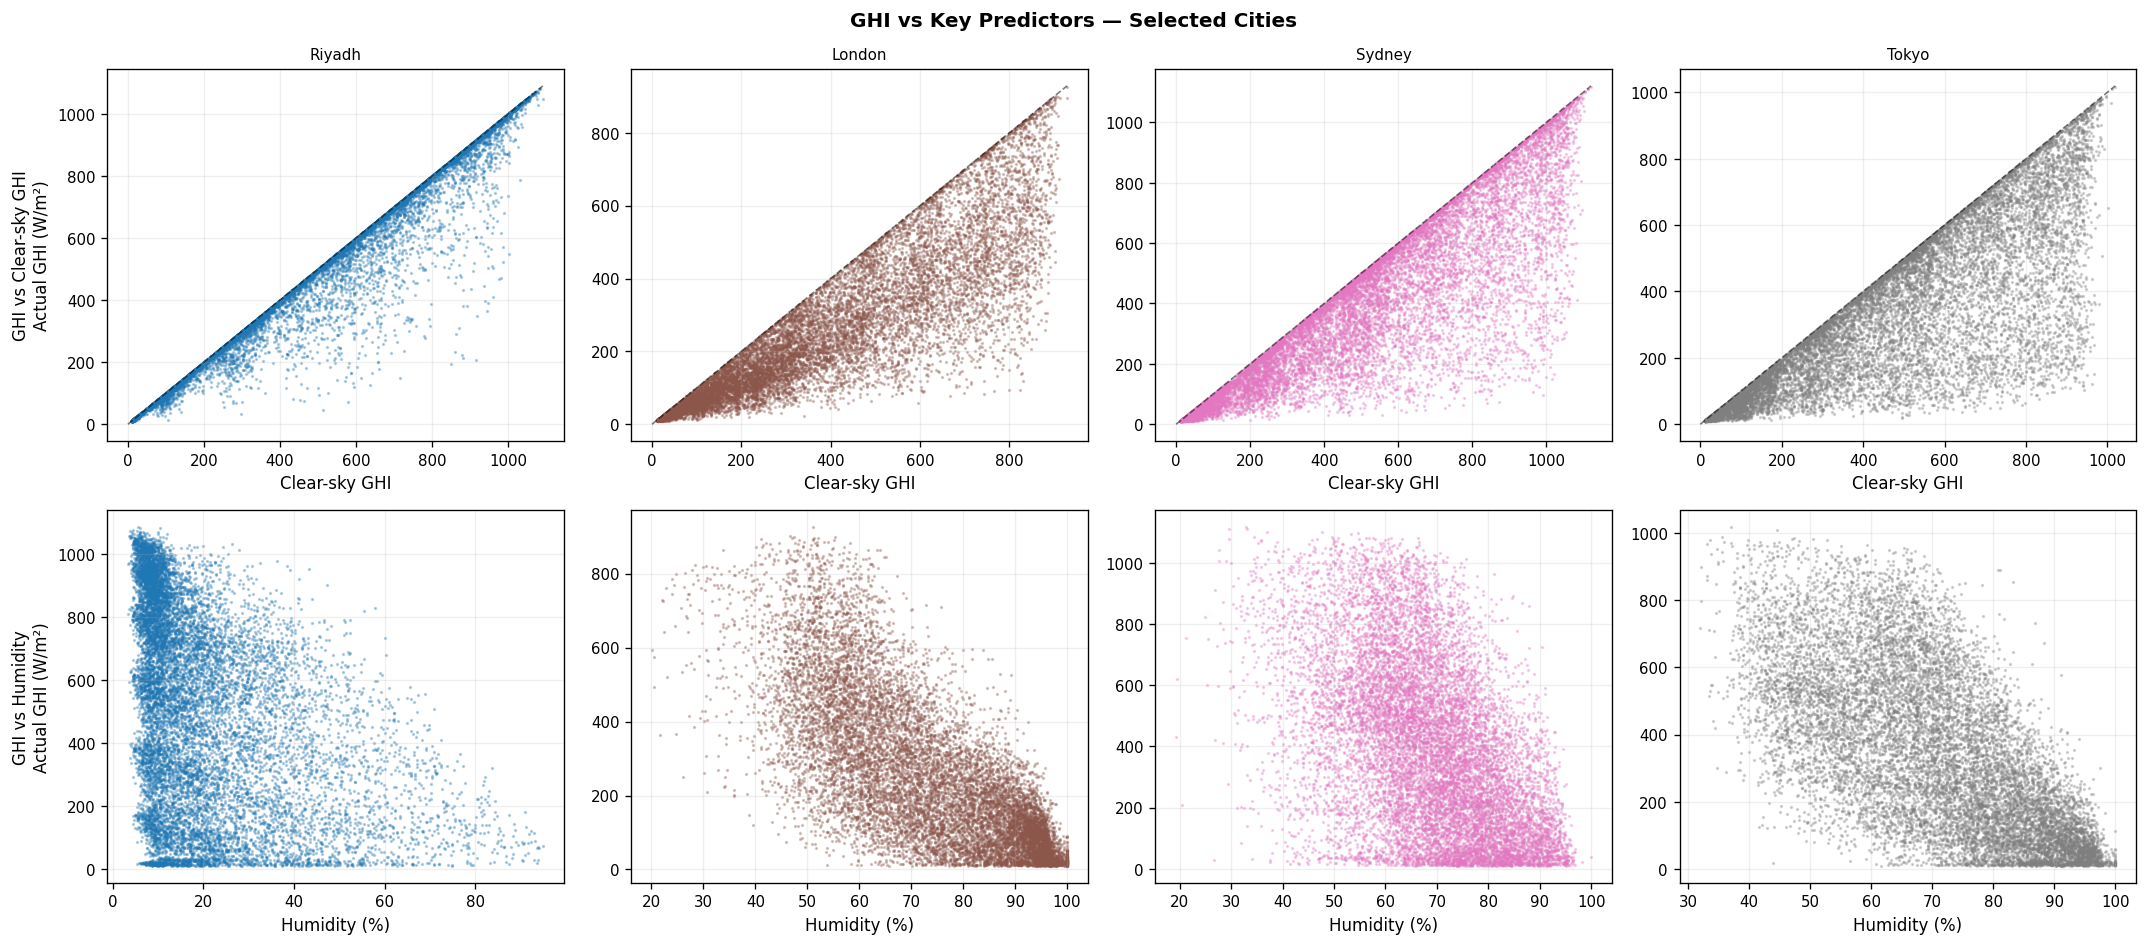

💾 Saved → ..\outputs/plots\03_ghi_scatter_correlates.png


In [5]:
# Find top 3 correlates with GHI per city (excluding GHI itself)
print("🔍 Top correlates with GHI per city:\n")
top_correlates = {}
for city in CITIES:
    df   = city_dfs[city][FEATURE_COLS]
    corr = df.corr()["GHI"].drop("GHI").abs().sort_values(ascending=False)
    top3 = corr.head(3).index.tolist()
    top_correlates[city] = top3
    print(f"  {city:<14}  {top3}")

# Plot GHI vs clear_sky_ghi and clearness_index for 4 diverse cities
sample_cities = ["riyadh", "london", "sydney", "tokyo"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("GHI vs Key Predictors — Selected Cities", fontsize=12, fontweight="bold")

for col_idx, city in enumerate(sample_cities):
    df      = city_dfs[city]
    daytime = df[df["is_daytime"]]

    # Row 1: GHI vs clear_sky_ghi
    ax = axes[0, col_idx]
    ax.scatter(
        daytime["clear_sky_ghi"], daytime["GHI"],
        s=1, alpha=0.3, color=CITY_COLORS[city]
    )
    # Perfect correlation line
    lim = max(daytime["clear_sky_ghi"].max(), daytime["GHI"].max())
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.5, label="y=x")
    ax.set_title(f"{city.replace('_',' ').title()}", fontsize=9)
    ax.set_xlabel("Clear-sky GHI")
    if col_idx == 0:
        ax.set_ylabel("Actual GHI (W/m²)")
    ax.grid(True, alpha=0.2)

    # Row 2: GHI vs humidity
    ax = axes[1, col_idx]
    ax.scatter(
        daytime["humidity"], daytime["GHI"],
        s=1, alpha=0.3, color=CITY_COLORS[city]
    )
    ax.set_xlabel("Humidity (%)")
    if col_idx == 0:
        ax.set_ylabel("Actual GHI (W/m²)")
    ax.grid(True, alpha=0.2)

axes[0, 0].set_ylabel("GHI vs Clear-sky GHI\nActual GHI (W/m²)")
axes[1, 0].set_ylabel("GHI vs Humidity\nActual GHI (W/m²)")

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "03_ghi_scatter_correlates.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

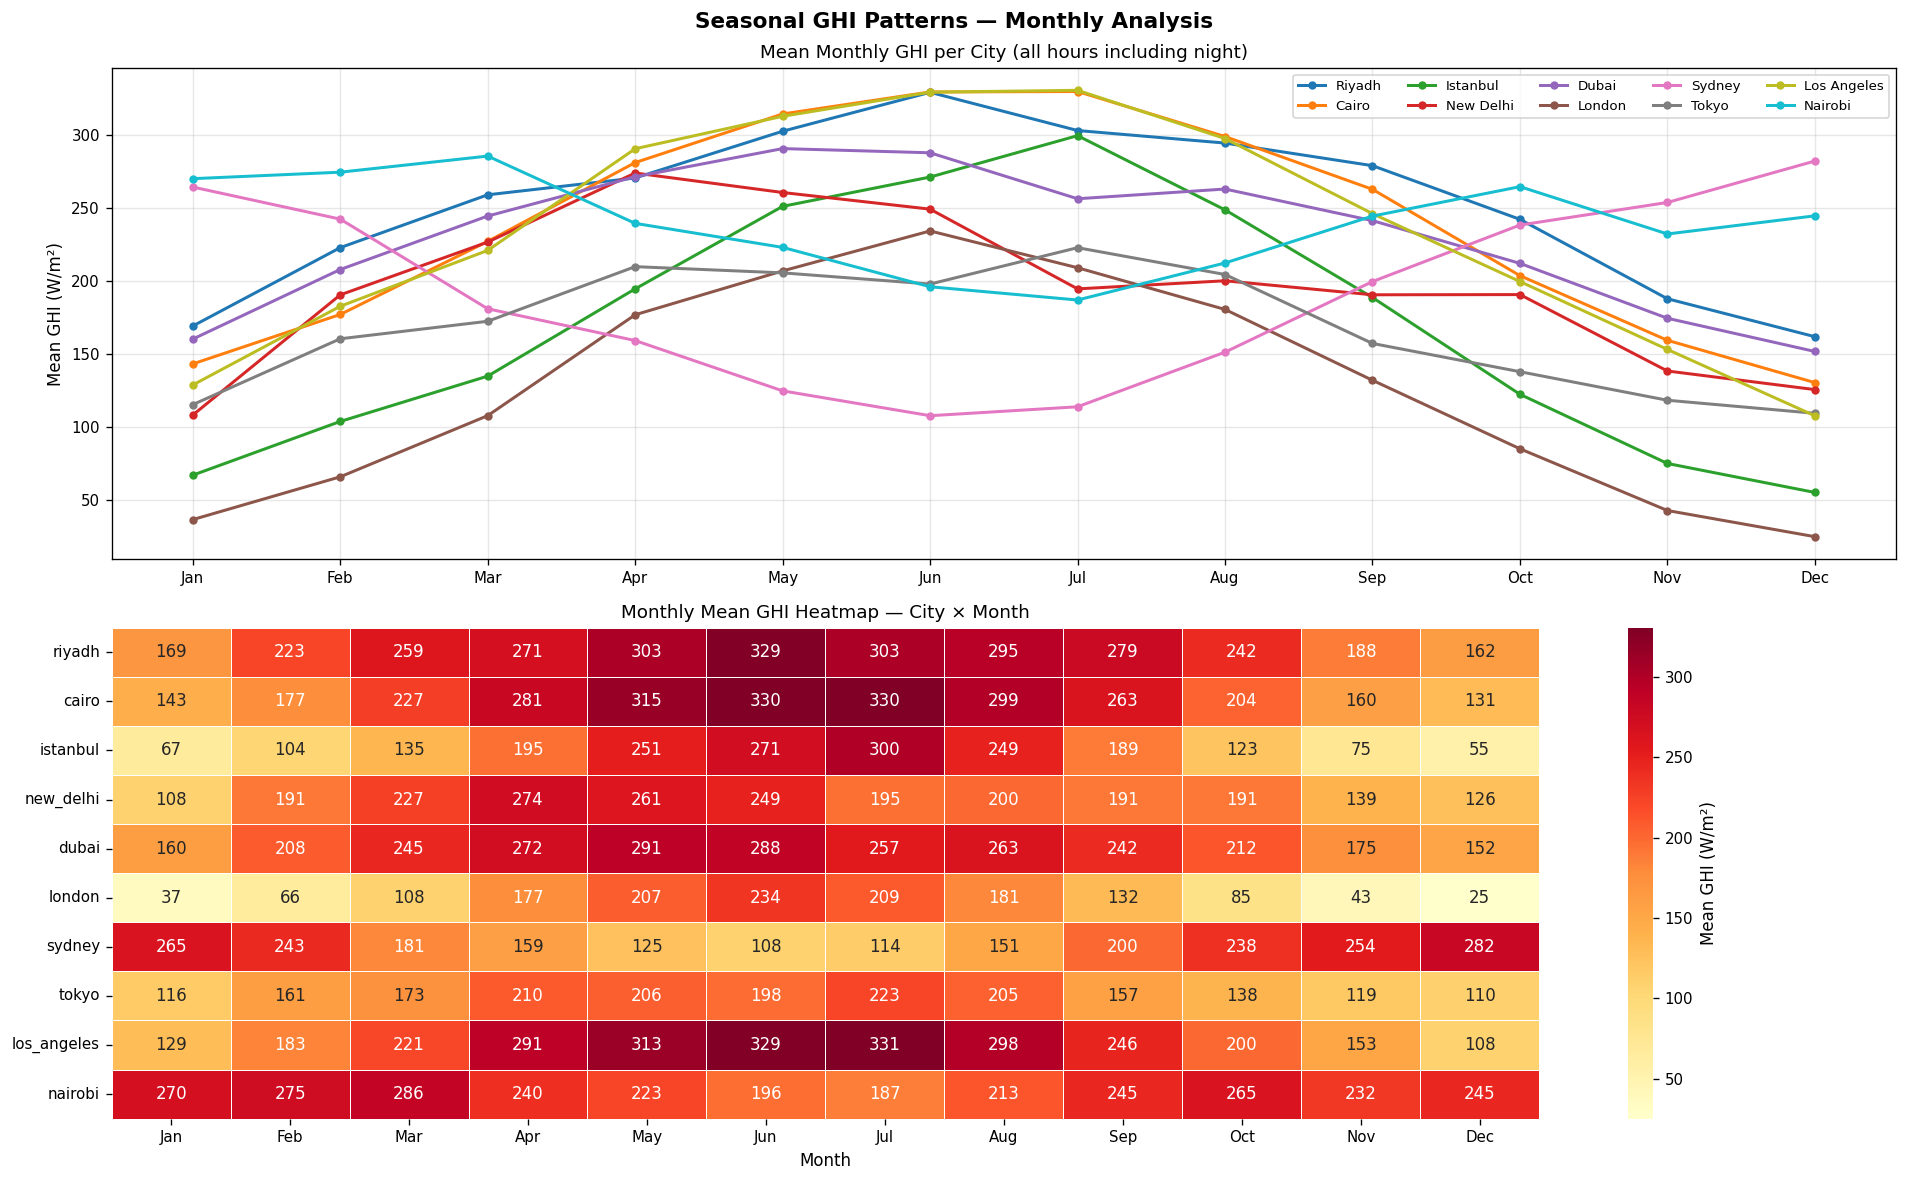

💾 Saved → ..\outputs/plots\03_seasonal_patterns.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("Seasonal GHI Patterns — Monthly Analysis", fontsize=13, fontweight="bold")

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# ── Plot 1: Mean monthly GHI per city ────────────────────────────
ax = axes[0]
for city in CITIES:
    df         = city_dfs[city]
    monthly    = df.groupby("month")["GHI"].mean()
    ax.plot(
        monthly.index, monthly.values,
        marker="o", markersize=4,
        label=city.replace("_", " ").title(),
        color=CITY_COLORS[city], linewidth=1.8
    )
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Mean GHI (W/m²)")
ax.set_title("Mean Monthly GHI per City (all hours including night)")
ax.legend(ncol=5, fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 2: Monthly GHI heatmap (city × month) ───────────────────
ax = axes[1]
monthly_matrix = pd.DataFrame({
    city: city_dfs[city].groupby("month")["GHI"].mean()
    for city in CITIES
}).T
monthly_matrix.columns = MONTH_NAMES

sns.heatmap(
    monthly_matrix, ax=ax,
    annot=True, fmt=".0f",
    cmap="YlOrRd", linewidths=0.5,
    cbar_kws={"label": "Mean GHI (W/m²)"}
)
ax.set_title("Monthly Mean GHI Heatmap — City × Month")
ax.set_xlabel("Month")
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "03_seasonal_patterns.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

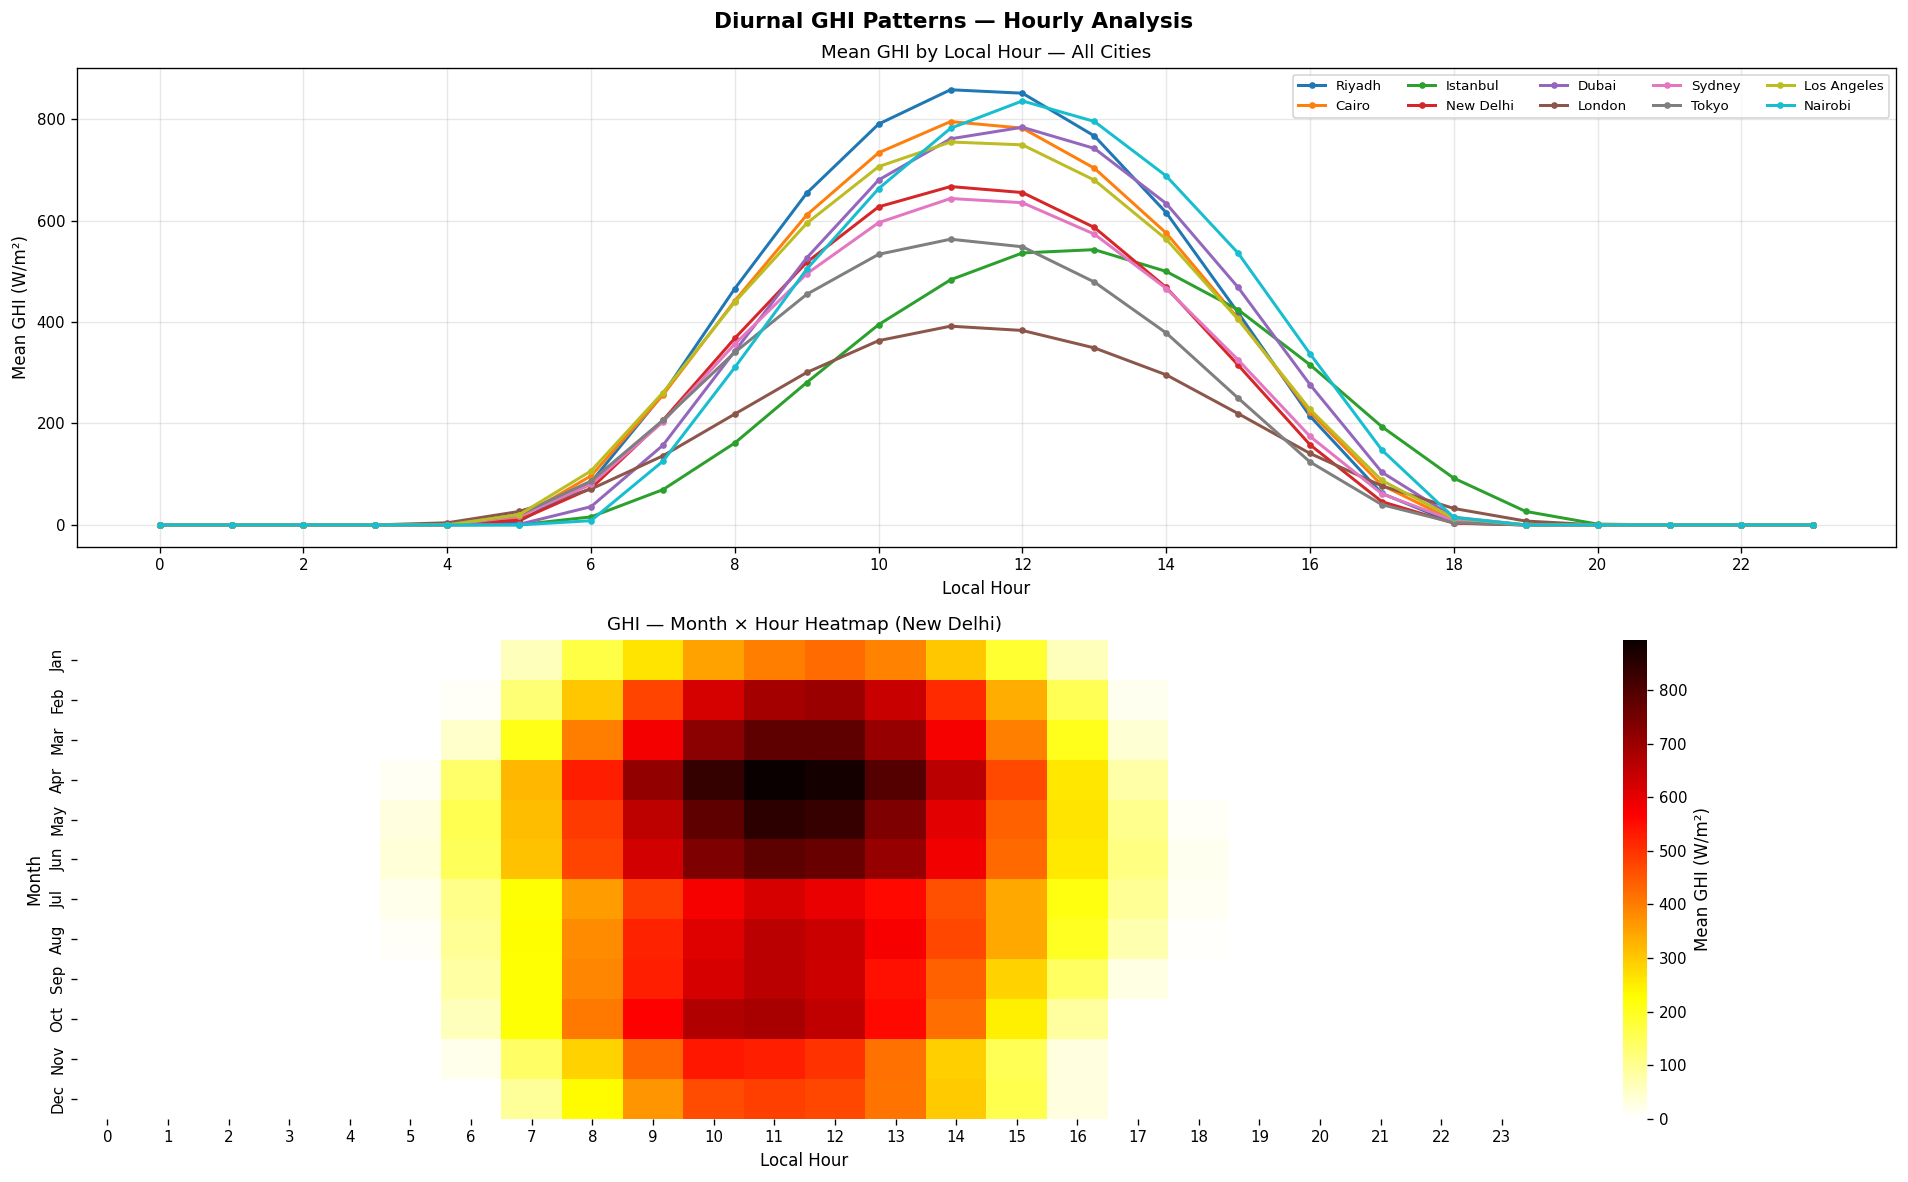

💾 Saved → ..\outputs/plots\03_diurnal_patterns.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("Diurnal GHI Patterns — Hourly Analysis", fontsize=13, fontweight="bold")

# ── Plot 1: Mean GHI by local hour ───────────────────────────────
ax = axes[0]
for city in CITIES:
    df       = city_dfs[city]
    by_hour  = df.groupby("local_hour")["GHI"].mean()
    ax.plot(
        by_hour.index, by_hour.values,
        marker="o", markersize=3,
        label=city.replace("_", " ").title(),
        color=CITY_COLORS[city], linewidth=1.8
    )
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Local Hour")
ax.set_ylabel("Mean GHI (W/m²)")
ax.set_title("Mean GHI by Local Hour — All Cities")
ax.legend(ncol=5, fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 2: Hourly GHI heatmap for one city (New Delhi) ──────────
ax = axes[1]
city  = "new_delhi"
df    = city_dfs[city]
pivot = df.groupby(["month", "local_hour"])["GHI"].mean().unstack()
pivot.index = MONTH_NAMES

sns.heatmap(
    pivot, ax=ax,
    cmap="hot_r", linewidths=0,
    cbar_kws={"label": "Mean GHI (W/m²)"}
)
ax.set_title(f"GHI — Month × Hour Heatmap ({city.replace('_',' ').title()})")
ax.set_xlabel("Local Hour")
ax.set_ylabel("Month")

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "03_diurnal_patterns.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

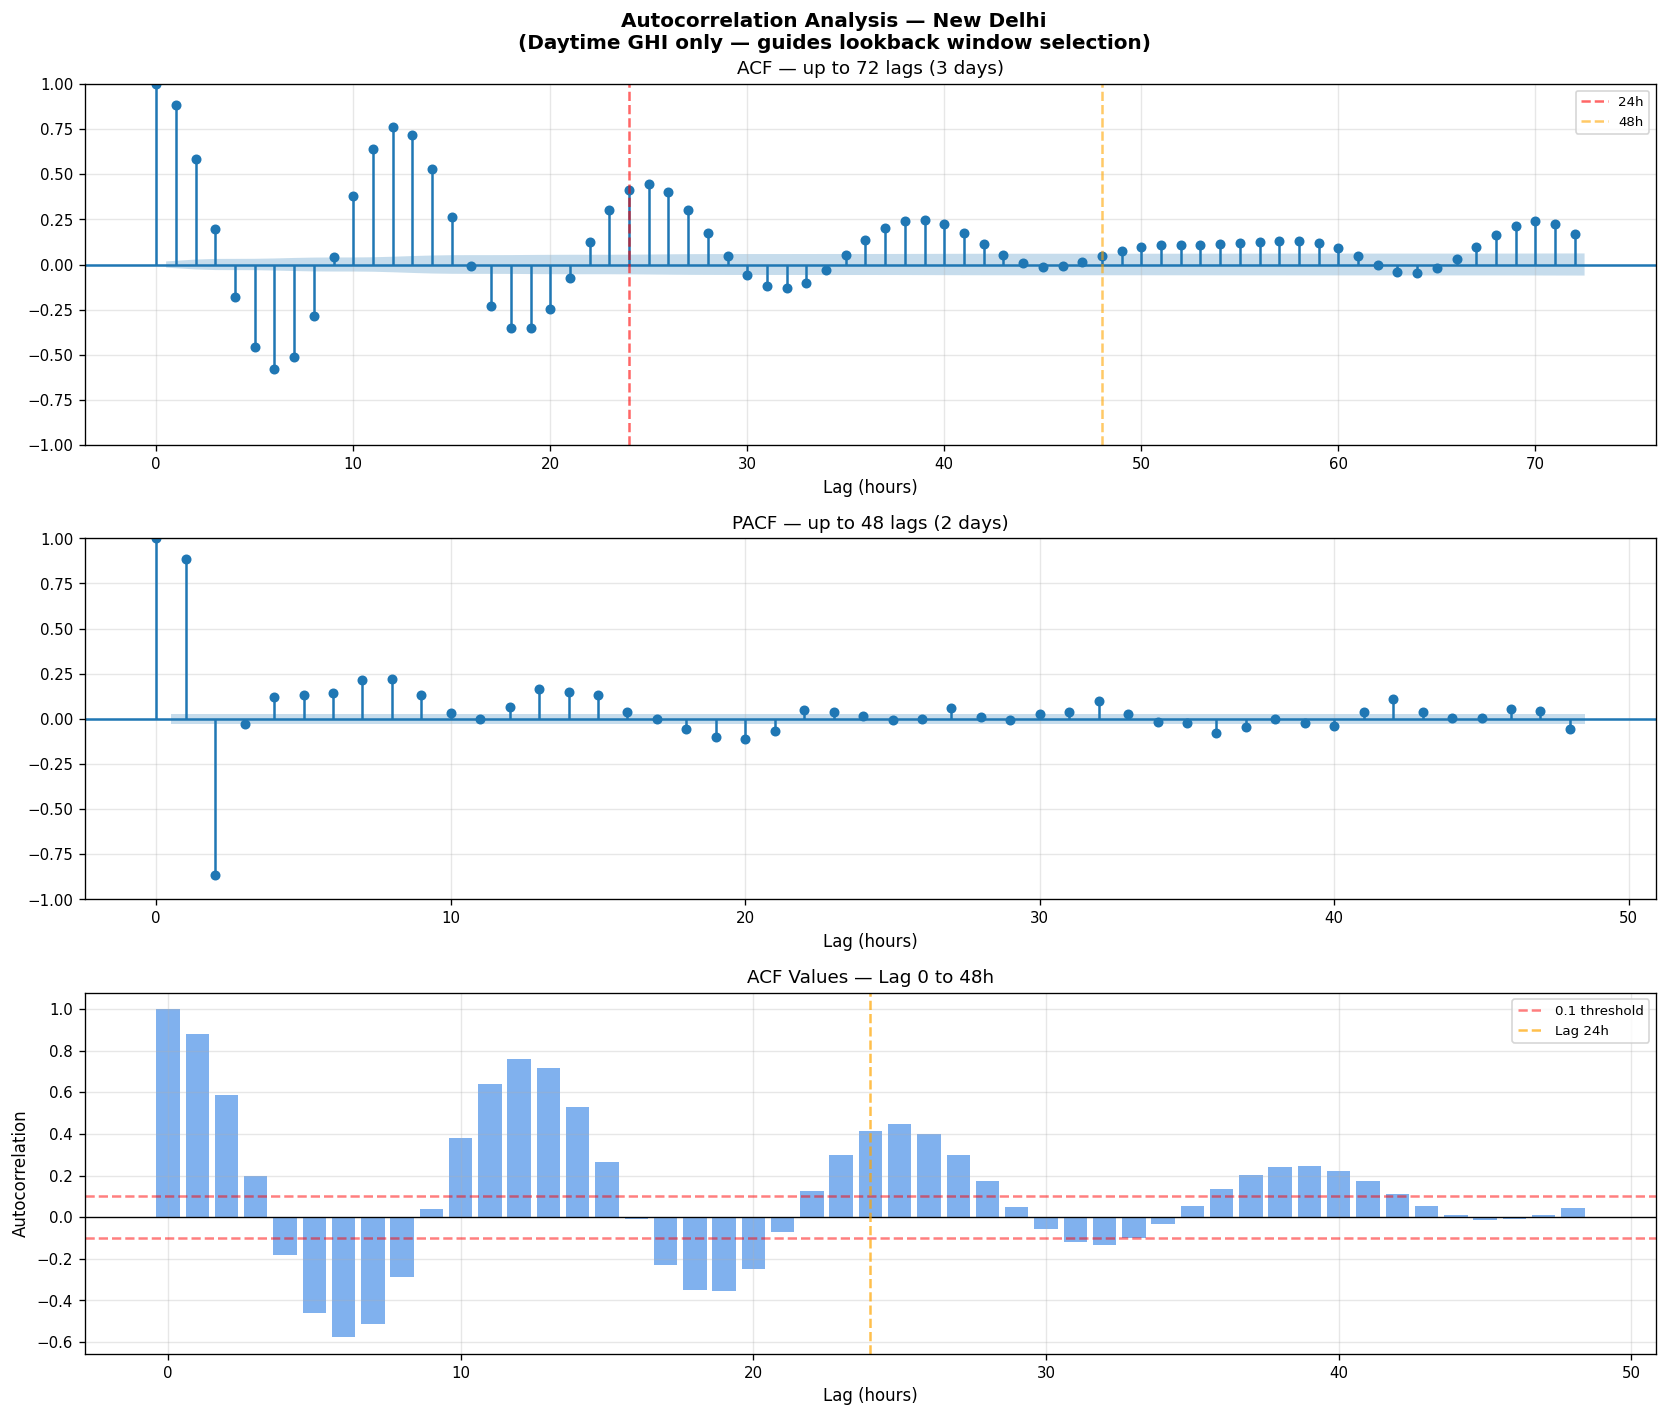


📊 Key ACF values for New Delhi daytime GHI:
   Lag   1h : 0.8824
   Lag   2h : 0.5855
   Lag   3h : 0.1968
   Lag   6h : -0.5774
   Lag  12h : 0.7597
   Lag  24h : 0.4136
   Lag  48h : 0.0459

✅ Config PAST_HOURS = 48h  ←  justified by ACF analysis
💾 Saved → ..\outputs/plots\03_autocorrelation.png


In [8]:
# This is critical for deciding PAST_HOURS lookback window
city   = "new_delhi"
df     = city_dfs[city]

# Use only daytime GHI to avoid the zero-inflation from night
daytime_ghi = df[df["is_daytime"]]["GHI"].values

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(
    f"Autocorrelation Analysis — {city.replace('_',' ').title()}\n"
    "(Daytime GHI only — guides lookback window selection)",
    fontsize=12, fontweight="bold"
)

# ── ACF up to 72 lags (3 days) ────────────────────────────────────
plot_acf(daytime_ghi, lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — up to 72 lags (3 days)")
axes[0].set_xlabel("Lag (hours)")
axes[0].axvline(x=24, color="red",    linestyle="--", alpha=0.6, label="24h")
axes[0].axvline(x=48, color="orange", linestyle="--", alpha=0.6, label="48h")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── PACF up to 48 lags ───────────────────────────────────────────
plot_pacf(daytime_ghi[:5000], lags=48, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF — up to 48 lags (2 days)")
axes[1].set_xlabel("Lag (hours)")
axes[1].grid(True, alpha=0.3)

# ── ACF values as bar chart ───────────────────────────────────────
acf_vals = acf(daytime_ghi, nlags=48, fft=True)
axes[2].bar(range(len(acf_vals)), acf_vals, color="#4A90E8", alpha=0.7, width=0.8)
axes[2].axhline(y=0,    color="black",  linewidth=0.8)
axes[2].axhline(y=0.1,  color="red",    linestyle="--", alpha=0.5, label="0.1 threshold")
axes[2].axhline(y=-0.1, color="red",    linestyle="--", alpha=0.5)
axes[2].axvline(x=24,   color="orange", linestyle="--", alpha=0.7, label="Lag 24h")
axes[2].set_title("ACF Values — Lag 0 to 48h")
axes[2].set_xlabel("Lag (hours)")
axes[2].set_ylabel("Autocorrelation")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "03_autocorrelation.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()

# Print key ACF values
print("\n📊 Key ACF values for New Delhi daytime GHI:")
for lag in [1, 2, 3, 6, 12, 24, 48]:
    if lag < len(acf_vals):
        print(f"   Lag {lag:>3}h : {acf_vals[lag]:.4f}")

print(f"\n✅ Config PAST_HOURS = {config.PAST_HOURS}h  ←  justified by ACF analysis")
print(f"💾 Saved → {path}")

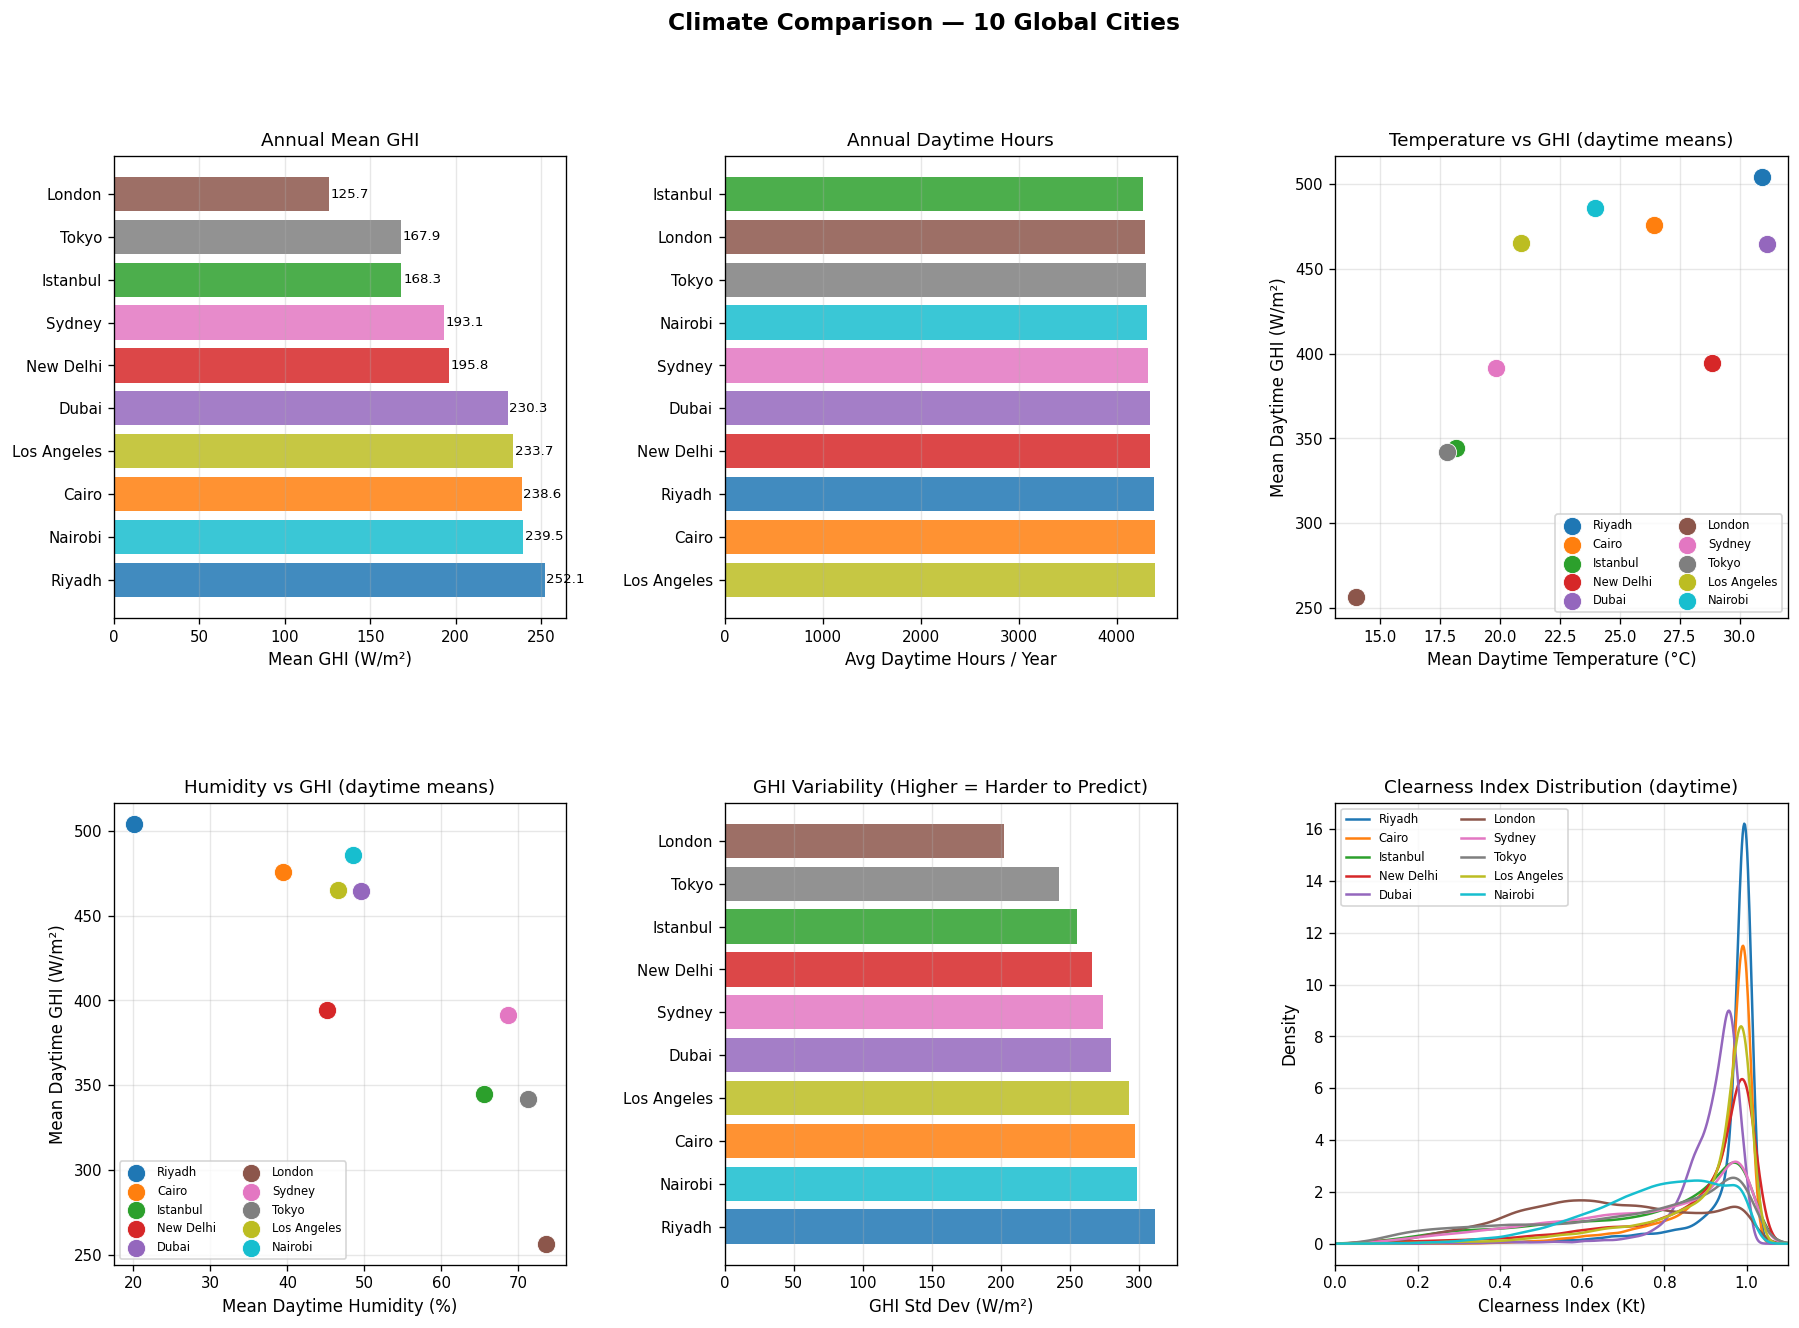

💾 Saved → ..\outputs/plots\03_climate_comparison.png


In [9]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Climate Comparison — 10 Global Cities", fontsize=14, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1: Annual mean GHI bar chart ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
annual_ghi = {
    city: city_dfs[city]["GHI"].mean()
    for city in CITIES
}
sorted_cities = sorted(annual_ghi, key=annual_ghi.get, reverse=True)
colors        = [CITY_COLORS[c] for c in sorted_cities]
bars = ax1.barh(
    [c.replace("_", " ").title() for c in sorted_cities],
    [annual_ghi[c] for c in sorted_cities],
    color=colors, alpha=0.85
)
ax1.set_xlabel("Mean GHI (W/m²)")
ax1.set_title("Annual Mean GHI")
ax1.grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars, [annual_ghi[c] for c in sorted_cities]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", fontsize=8)

# ── 2: Daytime hours per year ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
daytime_hours = {
    city: city_dfs[city]["is_daytime"].sum() / 3
    for city in CITIES
}
sorted_c2 = sorted(daytime_hours, key=daytime_hours.get, reverse=True)
ax2.barh(
    [c.replace("_", " ").title() for c in sorted_c2],
    [daytime_hours[c] for c in sorted_c2],
    color=[CITY_COLORS[c] for c in sorted_c2], alpha=0.85
)
ax2.set_xlabel("Avg Daytime Hours / Year")
ax2.set_title("Annual Daytime Hours")
ax2.grid(True, alpha=0.3, axis="x")

# ── 3: Temperature vs GHI scatter ────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for city in CITIES:
    df      = city_dfs[city]
    daytime = df[df["is_daytime"]]
    ax3.scatter(
        daytime["temperature"].mean(),
        daytime["GHI"].mean(),
        s=120, color=CITY_COLORS[city],
        label=city.replace("_", " ").title(),
        zorder=3, edgecolors="white", linewidths=0.5
    )
ax3.set_xlabel("Mean Daytime Temperature (°C)")
ax3.set_ylabel("Mean Daytime GHI (W/m²)")
ax3.set_title("Temperature vs GHI (daytime means)")
ax3.legend(fontsize=7, ncol=2)
ax3.grid(True, alpha=0.3)

# ── 4: Humidity vs GHI scatter ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for city in CITIES:
    df      = city_dfs[city]
    daytime = df[df["is_daytime"]]
    ax4.scatter(
        daytime["humidity"].mean(),
        daytime["GHI"].mean(),
        s=120, color=CITY_COLORS[city],
        label=city.replace("_", " ").title(),
        zorder=3, edgecolors="white", linewidths=0.5
    )
ax4.set_xlabel("Mean Daytime Humidity (%)")
ax4.set_ylabel("Mean Daytime GHI (W/m²)")
ax4.set_title("Humidity vs GHI (daytime means)")
ax4.legend(fontsize=7, ncol=2)
ax4.grid(True, alpha=0.3)

# ── 5: GHI variability (std) per city ────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ghi_std = {
    city: city_dfs[city][city_dfs[city]["is_daytime"]]["GHI"].std()
    for city in CITIES
}
sorted_c5 = sorted(ghi_std, key=ghi_std.get, reverse=True)
ax5.barh(
    [c.replace("_", " ").title() for c in sorted_c5],
    [ghi_std[c] for c in sorted_c5],
    color=[CITY_COLORS[c] for c in sorted_c5], alpha=0.85
)
ax5.set_xlabel("GHI Std Dev (W/m²)")
ax5.set_title("GHI Variability (Higher = Harder to Predict)")
ax5.grid(True, alpha=0.3, axis="x")

# ── 6: Clearness index distribution ──────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
for city in CITIES:
    df      = city_dfs[city]
    daytime = df[df["is_daytime"]]["clearness_index"]
    daytime.plot.kde(
        ax=ax6, label=city.replace("_", " ").title(),
        color=CITY_COLORS[city], linewidth=1.5
    )
ax6.set_xlabel("Clearness Index (Kt)")
ax6.set_title("Clearness Index Distribution (daytime)")
ax6.set_xlim(0, 1.1)
ax6.legend(fontsize=7, ncol=2)
ax6.grid(True, alpha=0.3)

path = os.path.join(PLOTS_DIR, "03_climate_comparison.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")